In [1]:
# =============================================================================
# TMO / tmopy Tutorial – Mouse Kidney
# =============================================================================
import os
import tmopy as tmo
import scanpy as sc
import matplotlib.pyplot as plt
import random
random.seed(8)

C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---------------------------------------------------------------------------
# 1. Setup paths
# ---------------------------------------------------------------------------
h5_file = "./data/10x_mouse_kidney/5k_Mouse_Kidney_MO_gemx_filtered_feature_bc_matrix.h5"
atac_annotation_file = "./data/10x_mouse_kidney/5k_Mouse_Kidney_MO_gemx_atac_peak_annotation.tsv"
output_dir = "./results/tmo_results_mouse_kidney_tmopy"
os.makedirs(output_dir, exist_ok=True)

In [3]:
# ---------------------------------------------------------------------------
# 2. Load and preprocess
# ---------------------------------------------------------------------------
adata = tmo.pp.read_10x_multiome(h5_file, atac_annotation_file)
print(adata)

C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


Added `interval` annotation for features from data\10x_mouse_kidney\5k_Mouse_Kidney_MO_gemx_filtered_feature_bc_matrix.h5


C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\mudata\_core\mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\mudata\_core\mudata.py:565: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr_legacy(attr, axis, join_common, **kwargs)
C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\mudata\_core\mudata.py:1272: FutureWarning: F

AnnData object with n_obs × n_vars = 4907 × 33696
    obs: 'n_genes'
    var: 'gene_ids', 'feature_types', 'genome', 'interval'
    uns: 'atac_annotation_file', 'peak_names'
    obsm: 'ATAC'


C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [4]:
# Compute Gene‑level ATAC (peaks -> genes)
adata = tmo.pp.compute_gene_level_atac(adata)
print("Gene-level ATAC matrix shape:", adata.obsm['ATAC_gene'].shape)

Building binary peak‑gene matrix...
M shape: (73918, 24712), non‑zeros: 90541
Peaks matched to genes: 72909/73918 (98.6%)
Computing gene‑activity matrix...
Gene‑activity shape: (4907, 24712), non‑zeros: 24344887
Gene-level ATAC matrix shape: (4907, 24712)


In [5]:
# Compute pseudotime, using Pax2 as early marker to orient the trajectory
adata = tmo.pp.compute_pseudotime(adata, root_marker="Pax2")
print(f"Pseudotime range: {adata.obs['pseudotime'].min():.3f} – {adata.obs['pseudotime'].max():.3f}")
print(f"Dataset reversed: {adata.uns.get('pseudotime_reversed', False)}")

Marker Pax2 correlates positively (r=0.026); keeping orientation.
Pseudotime range: 0.000 – 1.000
Pseudotime range: 0.000 – 1.000
Dataset reversed: False


C:\Users\phabe\miniconda3\envs\tmo_env\lib\site-packages\anndata\_core\anndata.py:1756: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [6]:
# ---------------------------------------------------------------------------
# 3. Annotate RNA components with GO terms (internet required)
# ---------------------------------------------------------------------------
component_annotation = tmo.tl.annotate_components(
    adata, n_components=50, n_top_genes=100, n_top_go=5, delay=2.0, organism='mouse'
)
component_annotation.head()

Running GO enrichment via Enrichr (delay 2.0s between requests)...


100%|██████████████████████████████████████████████████████████████████████████████████| 50/50 [02:36<00:00,  3.13s/it]


,Component,Top_genes,GO_terms
0,Comp0,"Fut9, Lrp2, Gm42397, Acsm2, Slc34a1, Slc27a2, ...",Nitrogen Compound Transport (GO:0071705); Aspa...
1,Comp1,"Erbb4, Mecom, Pkhd1, Egf, Slit2, Abca13, Slc12...",Potassium Ion Import Across Plasma Membrane (G...
2,Comp2,"Slc5a12, Magi2, Nox4, Angpt1, Gatm, Atp11a, Bn...",Amino Acid Transport (GO:0006865); Carboxylic ...
3,Comp3,"Meis2, Phactr1, Pbx1, Ldb2, Prkg1, Ebf1, Maml2...",Regulation Of Vascular Associated Smooth Muscl...
4,Comp4,"Plcb1, Slc12a1, Erbb4, Egf, Pdgfd, Dnm3, Umod,...",Regulation Of Small GTPase Mediated Signal Tra...


In [7]:
# ---------------------------------------------------------------------------
# 4. Train asymmetric model
#    (automatically saves best checkpoint + pca.pkl, tfidf.pkl, lsi.pkl)
# ---------------------------------------------------------------------------
model = tmo.tl.train_asymmetric(
    adata,
    epochs=50,
    val_interval=5,
    lambda_lag=0.1,
    batch_size=32,
    lr=1e-3,
    device='cpu',          # change to 'cuda' if GPU available
    save_model=os.path.join(output_dir, "tmo_asymmetric_best.pt"),
    output_dir=output_dir
)

Epoch  1 | recon 5.9732  lag 0.0049  LCS 0.6713
  -> Best model saved (LCS=0.6713)
Epoch  5 | recon 0.1025  lag 0.0002  LCS 0.9255
  -> Best model saved (LCS=0.9255)
Epoch 10 | recon 0.0487  lag 0.0002  LCS 0.9600
  -> Best model saved (LCS=0.9600)
Epoch 15 | recon 0.0318  lag 0.0002  LCS 0.8980
Epoch 20 | recon 0.0261  lag 0.0003  LCS 0.9223
Epoch 25 | recon 0.0190  lag 0.0002  LCS 0.9290
Epoch 30 | recon 0.0182  lag 0.0002  LCS 0.9365
Epoch 35 | recon 0.0169  lag 0.0001  LCS 0.9711
  -> Best model saved (LCS=0.9711)
Epoch 40 | recon 0.0147  lag 0.0001  LCS 0.9659
Epoch 45 | recon 0.0119  lag 0.0001  LCS 0.9785
  -> Best model saved (LCS=0.9785)
Epoch 50 | recon 0.0117  lag 0.0001  LCS 0.9682
Training finished. Best LCS: 0.9785


In [8]:
# ---------------------------------------------------------------------------
# (Optional) Train symmetric baseline for comparison
# ---------------------------------------------------------------------------
sym_model = tmo.tl.train_symmetric(
    adata,
    epochs=50,
    val_interval=5,
    batch_size=32,
    lr=1e-3,
    device='cpu',
    save_model=os.path.join(output_dir, "tmo_symmetric_best.pt"),
    output_dir=output_dir
)

Epoch  1 | recon 4.9581  LCS -0.0090
  -> Best model saved (LCS=-0.0090)
Epoch  5 | recon 0.0868  LCS -0.0071
  -> Best model saved (LCS=-0.0071)
Epoch 10 | recon 0.0375  LCS 0.0080
  -> Best model saved (LCS=0.0080)
Epoch 15 | recon 0.0273  LCS 0.0045
Epoch 20 | recon 0.0220  LCS 0.0042
Epoch 25 | recon 0.0169  LCS 0.0005
Epoch 30 | recon 0.0144  LCS 0.0018
Epoch 35 | recon 0.0131  LCS 0.0163
  -> Best model saved (LCS=0.0163)
Epoch 40 | recon 0.0126  LCS 0.0102
Epoch 45 | recon 0.0107  LCS 0.0019
Epoch 50 | recon 0.0104  LCS 0.0098
Training finished. Best LCS: 0.0163


In [9]:
# ---------------------------------------------------------------------------
# 5. Evaluate asymmetric model -> Δτ heatmap (Figure 1)
# ---------------------------------------------------------------------------
delta_tau, pt_grid, lcs, row_labels = tmo.tl.evaluate_asymmetric(
    adata,
    model_path=os.path.join(output_dir, "tmo_asymmetric_best.pt"),
    n_components=50,
    cluster_aggregate=True,
    dist_threshold=1.0,
    standardize=True
)
print(f"Lag Concordance Score (LCS): {lcs:.4f}")

Dataset not reversed; Δτ signs kept as computed.
LCS (raw, for validation) = 0.5717
Retained 50 / 50 components for clustering (0 removed due to constant / NaN profiles).
Standardized Δτ profiles for clustering.
Number of clusters at threshold 1.0: 15
Lag Concordance Score (LCS): 0.5717


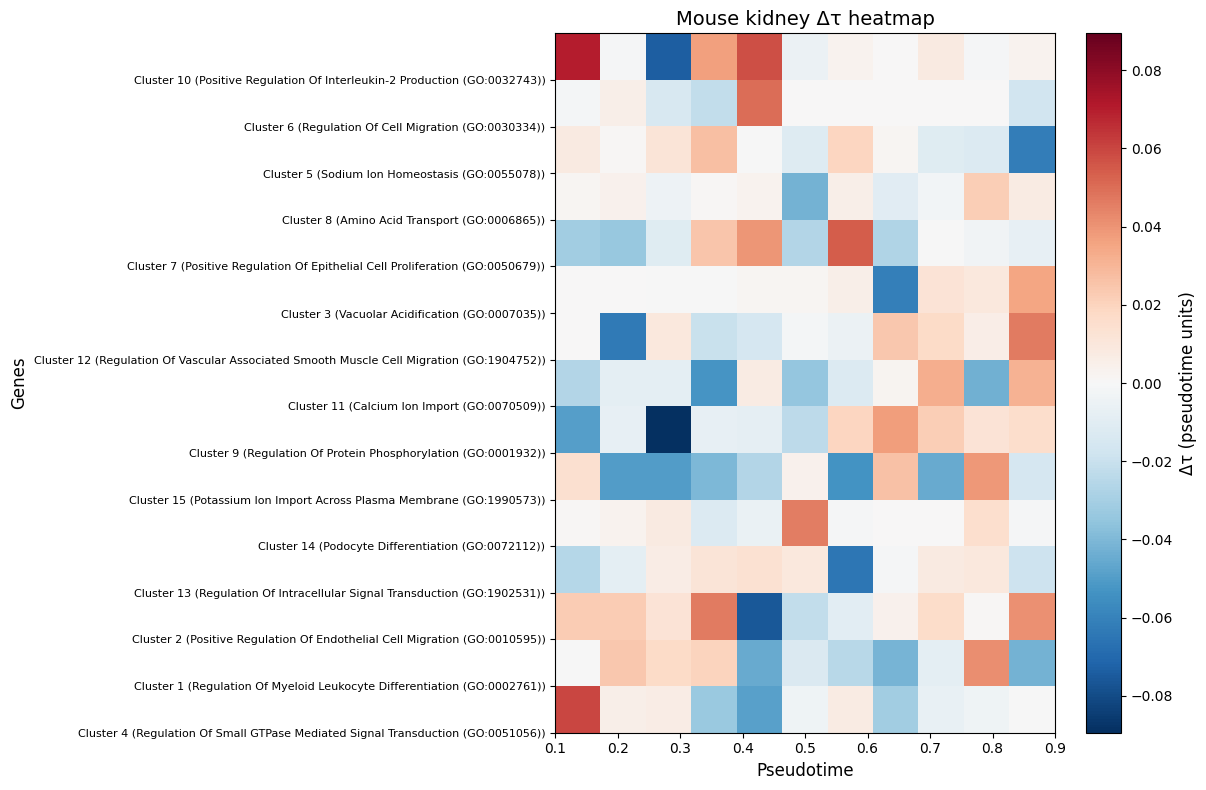

In [10]:
# Plot heatmap
fig1 = tmo.pl.plot_delta_tau(
    delta_tau,
    pt_grid,
    row_labels,
    title="Mouse kidney Δτ heatmap",
    save=os.path.join(output_dir, "fig1_delta_tau.pdf"),
    show=False
)
plt.show()
plt.close(fig1)

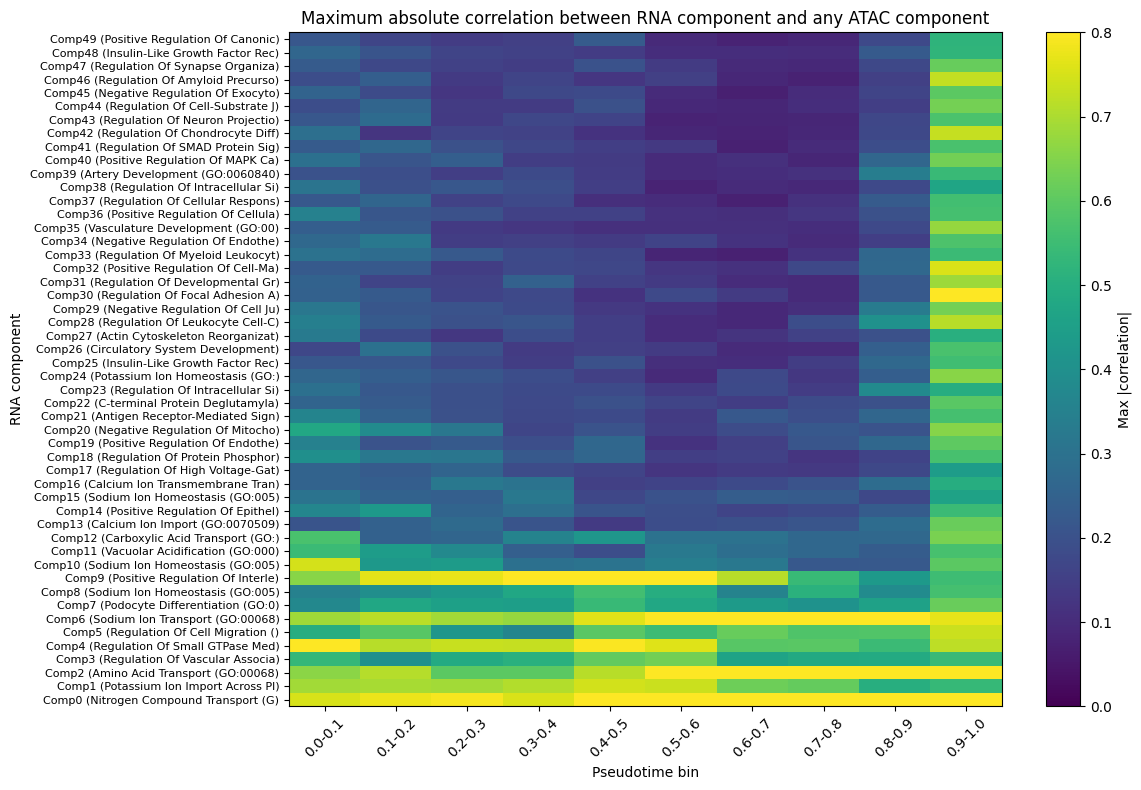

In [11]:
# ---------------------------------------------------------------------------
# 6. ATAC‑RNA correlation heatmap (Figure 2)
# ---------------------------------------------------------------------------
fig2 = tmo.pl.plot_correlation(
    adata,
    n_bins=10,
    save=os.path.join(output_dir, "fig2_correlation.pdf"),
    show=False
)
plt.show()
plt.close(fig2)


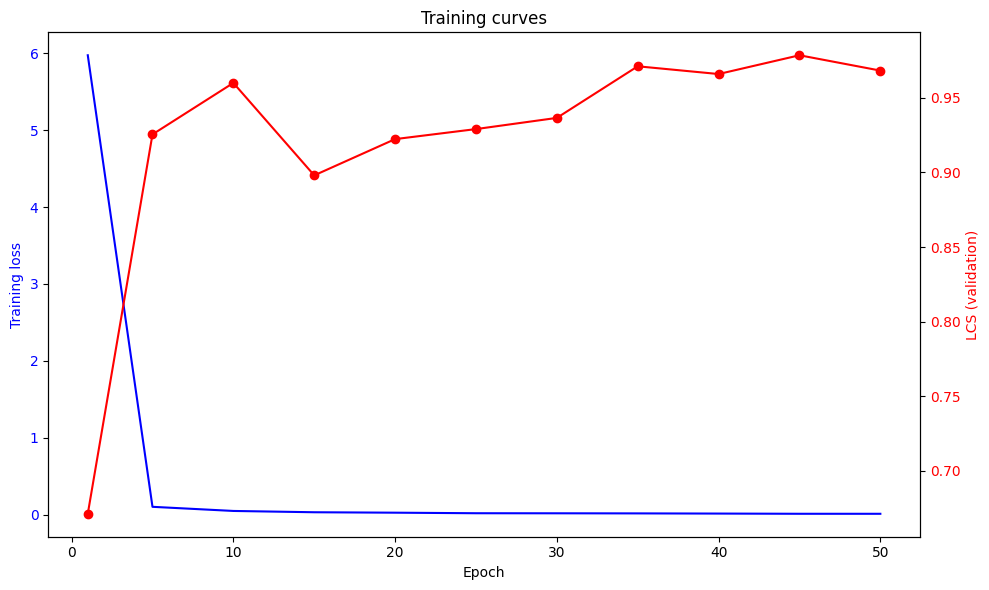

In [12]:
# ---------------------------------------------------------------------------
# 7. Plot training curves (Figure 3)
#    The training script saved a CSV file in the output directory.
# ---------------------------------------------------------------------------
metrics_csv = os.path.join(output_dir, "training_metrics_tmo_asymmetric.csv")
if os.path.exists(metrics_csv):
    fig3 = tmo.pl.plot_training_curves(
        metrics_csv,
        save=os.path.join(output_dir, "fig3_training_curves.pdf"),
        show=False
    )
    plt.show()
    plt.close(fig3)
else:
    print("Training metrics CSV not found; please adjust path.")


In [13]:
# ---------------------------------------------------------------------------
# 8. ChIP‑seq validation for Hnf4a (two‑sided)
# ---------------------------------------------------------------------------
target_file = "./data/10x_mouse_kidney/Hnf4a_top500_genes.txt"
if os.path.exists(target_file):
    print("Running ChIP‑seq validation for Hnf4a...")
    # Pre‑fitted transformers are saved automatically by train_asymmetric,
    # but for a quick run you can omit them; the function will still work.
    chip_res = tmo.tl.validate_chipseq(
        adata,
        model_path=os.path.join(output_dir, "tmo_asymmetric_best.pt"),
        target_genes_file=target_file,
        match_expression=True,
        n_components=50,
        alternative='two-sided',
        pca=os.path.join(output_dir,"pca.pkl"),   # optional, for exact reproducibility
        tfidf=os.path.join(output_dir,"tfidf.pkl"),
        lsi=os.path.join(output_dir,"lsi.pkl")
    )
    print(f"ChIP‑seq validation p‑value: {chip_res['p_value']:.4e}")
    print(f"Target Δτ mean: {chip_res['mean_target']:.6f}, background Δτ mean: {chip_res['mean_background']:.6f}")
else:
    print(f"Target gene file {target_file} not found. Skipping ChIP‑seq validation.")

Running ChIP‑seq validation for Hnf4a...
Target genes found: 491
Expression‑matched background genes: 491

=== CCF‑based Δτ validation ===
Target Δτ mean: 0.004094, background Δτ mean: 0.003466
Mann‑Whitney U: 132321.0, p = 7.9948e-03
ChIP‑seq validation p‑value: 7.9948e-03
Target Δτ mean: 0.004094, background Δτ mean: 0.003466


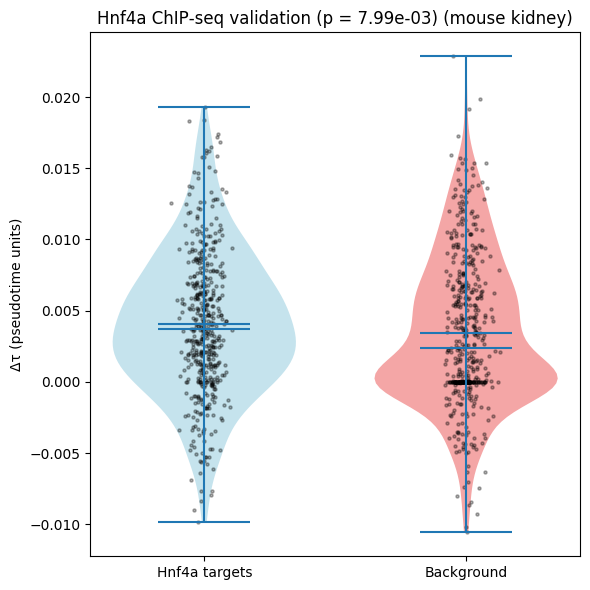

ChIP‑seq validation figure saved to fig4_chipseq_Hnf4a.pdf


In [14]:
# ---------------------------------------------------------------------------
# 9. Violin plot for ChIP‑seq
# ---------------------------------------------------------------------------
if 'chip_res' in locals() and chip_res['p_value']:
    p_val = chip_res['p_value']
    fig4 = tmo.pl.plot_violin_validation(
        chip_res['target_lags'], chip_res['background_lags'],
        target_label="Hnf4a targets",
        background_label="Background",
        title=f"Hnf4a ChIP‑seq validation (p = {p_val:.2e}) (mouse kidney)",
        ylabel="Δτ (pseudotime units)",
        save=os.path.join(output_dir, "fig4_chipseq_Hnf4a.pdf"),
        show=False
    )
    plt.show()
    plt.close(fig4)
    print("ChIP‑seq validation figure saved to fig4_chipseq_Hnf4a.pdf")
else:
    print("Run ChIP-seq validation first, to compute p-values.")

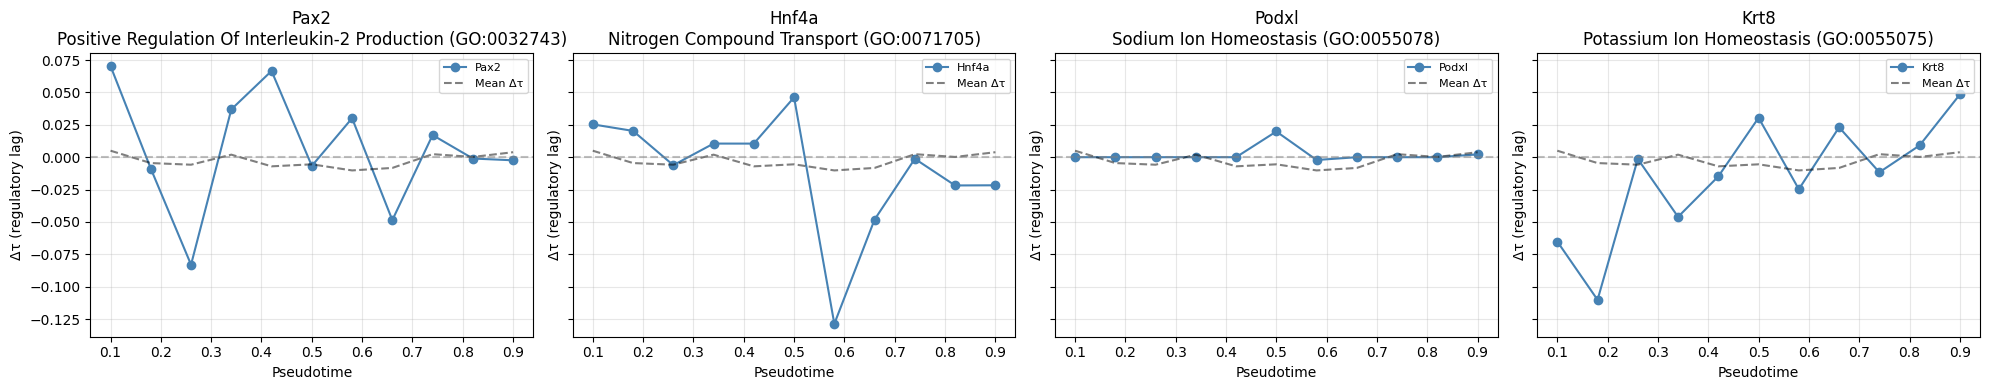

In [17]:
# ---------------------------------------------------------------------------
# (Optional) Marker gene Δτ profiles
# ---------------------------------------------------------------------------
fig_markers = tmo.pl.plot_marker_profiles(
    adata,
    marker_genes=["Pax2", "Hnf4a", "Podxl", "Krt8"],
    save=os.path.join(output_dir, "marker_profiles.pdf"),
    show=False
)
plt.show()
plt.close(fig_markers)

In [16]:
# ---------------------------------------------------------------------------
# 10. Summary
# ---------------------------------------------------------------------------
print("\nAnalysis completed. Results saved in:", output_dir)
print("Figure 1: Δτ heatmap (fig1_delta_tau.pdf)")
print("Figure 2: ATAC‑RNA correlation (fig2_correlation.pdf)")
print("Figure 3: Training curves (fig3_training_curves.pdf)")


Analysis completed. Results saved in: ./results/tmo_results_mouse_kidney_tmopy
Figure 1: Δτ heatmap (fig1_delta_tau.pdf)
Figure 2: ATAC‑RNA correlation (fig2_correlation.pdf)
Figure 3: Training curves (fig3_training_curves.pdf)
